# ExoScout v0.4 — Feature Importance and Error Analysis

This notebook investigates which features contribute most to the Random Forest predictions and which types of observations the model misclassifies.

All analysis is performed using only the development set. The final holdout remains untouched because it will be used only once, after the final pipeline has been selected. Inspecting it or making decisions based on it would compromise its role as an independent final evaluation.

A high feature importance indicates that the model relies strongly on the information contained in that feature. However, it does not prove that the feature is essential, nor that it has a causal relationship with the target.

## Evaluation Strategy

Error analysis is based on out-of-fold predictions from the development set.

For each cross-validation fold, the model is trained on four folds and predicts observations in the remaining unseen fold. The process is repeated until every development observation has received a prediction from a model that was not trained on it.

The folds remain group-aware using TIC ID (`tid`), preventing TOIs belonging to the same host star from appearing in both the training and validation portions of a fold.

The final holdout is not used during this analysis.

In [1]:
import sys
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.load_data import load_data

df = load_data()

In [2]:
df.shape


(8113, 10)

## Data Preparation

The NASA TOI catalog is filtered to observations labeled as Confirmed Planets (`CP`), Known Planets (`KP`), or False Positives (`FP`).

`CP` and `KP` are mapped to the positive class (`1`), while `FP` is mapped to the negative class (`0`).

The model uses seven transit and stellar features. TIC ID (`tid`) is excluded from the predictive features and retained only as a grouping variable.

In [3]:
filtered_df = df[df["tfopwg_disp"].isin(["CP", "KP", "FP"])].copy()

mapping = {
    "CP": 1,
    "KP": 1,
    "FP": 0
}

filtered_df["target"] = filtered_df["tfopwg_disp"].map(mapping)

In [4]:
features = [
    "pl_orbper",
    "pl_trandurh",
    "pl_trandep",
    "st_tmag",
    "st_teff",
    "st_logg",
    "st_rad"
]

X = filtered_df[features]
Y = filtered_df["target"]
groups = filtered_df["tid"]

## Group-Aware Development and Holdout Split

The same group-aware split introduced in v0.3 is reconstructed to preserve the existing evaluation protocol.

One fold, approximately 20% of the labeled data, is reserved as the final holdout. The remaining observations form the development set used throughout v0.4.

TIC ID (`tid`) is used as the grouping variable, ensuring that TOIs belonging to the same host star cannot appear in both partitions.

The final holdout remains untouched during feature analysis, error analysis, and model selection.

In [5]:
from sklearn.model_selection import StratifiedGroupKFold

holdout_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [6]:
dev_idx, holdout_idx = next(
    holdout_splitter.split(X, Y, groups=groups)
)

In [8]:
dev_idx[:10]

array([ 0,  1,  2,  3,  6,  7,  8,  9, 10, 11])

In [9]:
X_dev = X.iloc[dev_idx]

X_dev.shape

(2077, 7)

In [10]:
X_holdout = X.iloc[holdout_idx]

X_holdout.shape

(519, 7)

In [11]:
Y_dev = Y.iloc[dev_idx]
Y_holdout = Y.iloc[holdout_idx]

In [12]:
Y_dev.shape, Y_holdout.shape

((2077,), (519,))

In [13]:
groups_dev = groups.iloc[dev_idx]
groups_holdout = groups.iloc[holdout_idx]

In [14]:
len(set(groups_dev) & set(groups_holdout))

0

The development and holdout sets share zero TIC IDs, confirming complete host-star separation.

## Group-Aware Cross-Validation

All v0.4 analyses are performed using 5-fold stratified group cross-validation on the development set.

Each validation observation is evaluated by a model that was not trained on it, while TIC ID (`tid`) prevents TOIs from the same host star appearing in both portions of a fold.

In [15]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Random Forest Pipeline

The v0.3 Random Forest pipeline is reused without changing its preprocessing or model parameters.

Missing numerical values are replaced with medians learned only from the corresponding training data. Missingness indicators are added so that the model can also use the presence of missing values as predictive information.

Keeping preprocessing inside the pipeline prevents information from the validation folds from influencing imputation.

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=42
        )
    )
])

## Out-of-Fold Predictions

Out-of-fold predictions are generated for every observation in the development set.

Each observation receives a predicted class and probability from a Random Forest pipeline trained without that observation or any other TOI belonging to the same host star.

In [17]:
import numpy as np

oof_predictions = np.full(
    len(X_dev),
    fill_value=-1,
    dtype=int
)

oof_probabilities = np.full(
    len(X_dev),
    fill_value=np.nan,
    dtype=float
)

oof_fold_ids = np.full(
    len(X_dev),
    fill_value=-1,
    dtype=int
)

### Fold Structure Check

Before generating predictions, the cross-validation folds are inspected to verify their sizes and confirm that no TIC ID is shared between the training and validation portions.

In [18]:
for fold_id, (fold_train_idx, fold_validation_idx) in enumerate(
    cv.split(
        X_dev,
        Y_dev,
        groups=groups_dev
    ),
    start=1
):
    train_groups = groups_dev.iloc[fold_train_idx]
    validation_groups = groups_dev.iloc[fold_validation_idx]

    shared_groups = set(train_groups) & set(validation_groups)

    print(
        f"Fold {fold_id}: "
        f"train={len(fold_train_idx)}, "
        f"validation={len(fold_validation_idx)}, "
        f"shared hosts={len(shared_groups)}"
    )

Fold 1: train=1662, validation=415, shared hosts=0
Fold 2: train=1662, validation=415, shared hosts=0
Fold 3: train=1662, validation=415, shared hosts=0
Fold 4: train=1661, validation=416, shared hosts=0
Fold 5: train=1661, validation=416, shared hosts=0


The five validation folds contain 415–416 observations each. No TIC ID is shared between the training and validation portions of any fold, confirming that the group-aware constraint is respected.


### Prediction Generation

For each fold, a fresh copy of the Random Forest pipeline is fitted on the training portion and used to predict the corresponding unseen validation portion.

Predicted classes, planet probabilities, and fold identifiers are stored in their original development-set positions.

In [19]:
from sklearn.base import clone

for fold_id, (fold_train_idx, fold_validation_idx) in enumerate(
    cv.split(
        X_dev,
        Y_dev,
        groups=groups_dev
    ),
    start=1
):
    X_train_fold = X_dev.iloc[fold_train_idx]
    Y_train_fold = Y_dev.iloc[fold_train_idx]

    X_validation_fold = X_dev.iloc[fold_validation_idx]

    fold_pipeline = clone(random_forest_pipeline)

    fold_pipeline.fit(
        X_train_fold,
        Y_train_fold
    )

    oof_predictions[fold_validation_idx] = (
        fold_pipeline.predict(X_validation_fold)
    )

    oof_probabilities[fold_validation_idx] = (
        fold_pipeline.predict_proba(X_validation_fold)[:, 1]
    )

    oof_fold_ids[fold_validation_idx] = fold_id

### Prediction Completeness Check

The stored outputs are checked to ensure that every development observation received a prediction, probability, and fold identifier.

In [20]:
missing_predictions = (oof_predictions == -1).sum()
missing_probabilities = np.isnan(oof_probabilities).sum()
missing_fold_ids = (oof_fold_ids == -1).sum()

print("Missing predictions:", missing_predictions)
print("Missing probabilities:", missing_probabilities)
print("Missing fold IDs:", missing_fold_ids)

Missing predictions: 0
Missing probabilities: 0
Missing fold IDs: 0


## Out-of-Fold Performance Check

The combined out-of-fold predictions are evaluated to verify that the manual validation loop remains consistent with the grouped cross-validation results reported in v0.3.

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

oof_accuracy = accuracy_score(
    Y_dev,
    oof_predictions
)

oof_precision = precision_score(
    Y_dev,
    oof_predictions
)

oof_recall = recall_score(
    Y_dev,
    oof_predictions
)

oof_f1 = f1_score(
    Y_dev,
    oof_predictions
)

print(f"Accuracy:  {oof_accuracy:.3f}")
print(f"Precision: {oof_precision:.3f}")
print(f"Recall:    {oof_recall:.3f}")
print(f"F1-score:  {oof_f1:.3f}")

Accuracy:  0.822
Precision: 0.802
Recall:    0.871
F1-score:  0.835


The pooled out-of-fold predictions achieved:

- Accuracy: 82.2%
- Planet precision: 80.2%
- Planet recall: 87.1%
- Planet F1-score: 83.5%

These results are consistent with the grouped cross-validation results reported in v0.3, confirming that the manual out-of-fold procedure reproduces the existing evaluation protocol.

Recall remains higher than precision: the model identifies most planet-class observations, while producing a larger proportion of false-positive planet predictions.

## Impurity-Based Feature Importance

A Random Forest pipeline is fitted on the complete development set to inspect its internal impurity-based feature importances.

These importances measure how much each input reduces classification impurity across the forest's decision trees. They describe how the fitted model uses its inputs, but do not establish causality or guarantee usefulness on unseen data.

Because impurity-based importance is derived from training statistics and can favor features with many possible split values, it will later be compared with out-of-fold permutation importance.

In [22]:
rf_dev_pipeline = clone(random_forest_pipeline)

rf_dev_pipeline.fit(
    X_dev,
    Y_dev
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pl_orbper','pl_trandurh','pl_trandep',...,'st_teff','st_logg','st_rad']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",True
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder fo

In [23]:
rf_dev_pipeline.named_steps["model"].feature_importances_

array([0.15503979, 0.13888935, 0.15556928, 0.10221987, 0.13117632,
       0.12288409, 0.14604294, 0.00207918, 0.00136276, 0.03342226,
       0.01131417])

In [24]:
fitted_imputer = rf_dev_pipeline.named_steps["imputer"]
fitted_random_forest = rf_dev_pipeline.named_steps["model"]

transformed_feature_names = (
    fitted_imputer.get_feature_names_out(features)
)

transformed_feature_names

array(['pl_orbper', 'pl_trandurh', 'pl_trandep', 'st_tmag', 'st_teff',
       'st_logg', 'st_rad', 'missingindicator_pl_orbper',
       'missingindicator_st_teff', 'missingindicator_st_logg',
       'missingindicator_st_rad'], dtype=object)

### Impurity-Based Importance Ranking

The importance values are matched with the transformed feature names and sorted from highest to lowest.

The values are normalized and sum to one. They represent each feature's relative contribution to impurity reduction within the fitted forest.


In [25]:
impurity_importance_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "impurity_importance": (
        fitted_random_forest.feature_importances_
    )
})

impurity_importance_df = (
    impurity_importance_df
    .sort_values(
        "impurity_importance",
        ascending=False
    )
    .reset_index(drop=True)
)

impurity_importance_df

,feature,impurity_importance
0,pl_trandep,0.155569
1,pl_orbper,0.155040
2,st_rad,0.146043
3,pl_trandurh,0.138889
4,st_teff,0.131176
5,st_logg,0.122884
6,st_tmag,0.102220
7,missingindicator_st_logg,0.033422
8,missingindicator_st_rad,0.011314
9,missingindicator_pl_orbper,0.002079


### Initial Impurity-Importance Observation

The seven original astronomical features have relatively distributed impurity importances, with no single feature dominating the fitted forest.

Transit depth (`pl_trandep`) and orbital period (`pl_orbper`) rank highest, closely followed by stellar radius (`st_rad`) and transit duration (`pl_trandurh`).

Missingness indicators account for a smaller share of the total importance. Among them, missingness in stellar surface gravity (`st_logg`) has the largest contribution.

These results describe the internal behavior of the fitted forest and are treated as preliminary until compared with out-of-fold permutation importance.

Matplotlib is building the font cache; this may take a moment.


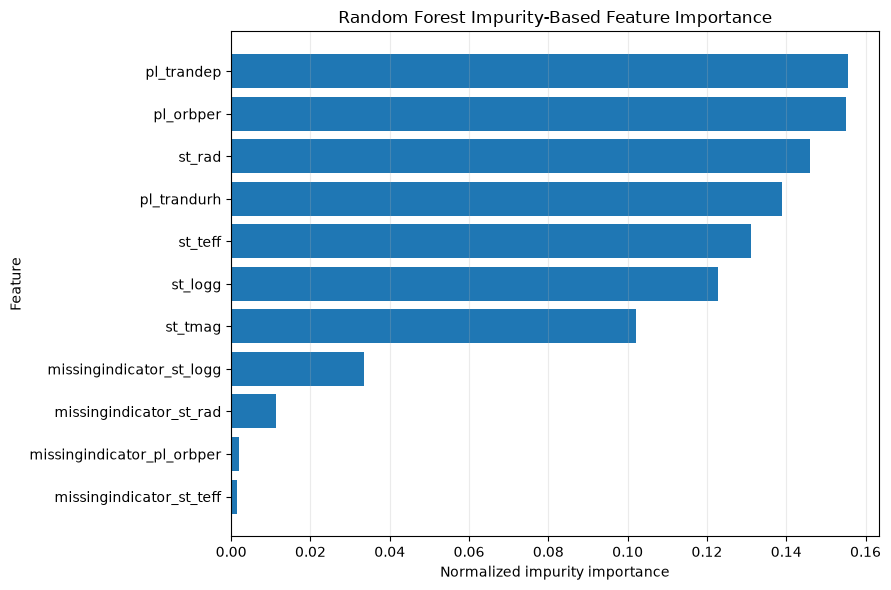

In [26]:
import matplotlib.pyplot as plt

impurity_plot_df = (
    impurity_importance_df
    .sort_values("impurity_importance")
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    impurity_plot_df["feature"],
    impurity_plot_df["impurity_importance"]
)

ax.set_title("Random Forest Impurity-Based Feature Importance")
ax.set_xlabel("Normalized impurity importance")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()
plt.show()